# 04 — Bidirectional LSTM (BiLSTM) Model

Input model:
- hanya menggunakan kolom `code`
- tidak menggunakan metadata seperti `problem_id`, `group_id`, `leakage_group`, `code_hash`, `dataset_origin`, `status_in_folder`, `LLM`, atau `hf_split` sebagai fitur

In [1]:
!pip -q install scikit-learn joblib

## 1. Import library dan mount Google Drive

Bagian ini memasang dependency, menghubungkan Google Drive, mengimpor library, dan menyiapkan path project/output.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import sys
import re
import json
import time
import joblib
import pickle
import random
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, callbacks, optimizers

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

PROJECT_DIR = "/content/drive/MyDrive/FP AI"
SRC_DIR = os.path.join(PROJECT_DIR, "src")
sys.path.append(SRC_DIR)

try:
    from config import *
    print("config.py loaded.")
except Exception:
    print("config.py not found. Using fallback paths.")
    RAW_DIR = os.path.join(PROJECT_DIR, "data", "raw")
    PROCESSED_DIR = os.path.join(PROJECT_DIR, "data", "processed")
    SPLIT_DIR = os.path.join(PROJECT_DIR, "data", "splits")
    EDA_DIR = os.path.join(PROJECT_DIR, "outputs", "eda")
    MODEL_DIR = os.path.join(PROJECT_DIR, "outputs", "models")
    PREDICTION_DIR = os.path.join(PROJECT_DIR, "outputs", "predictions")
    METRIC_DIR = os.path.join(PROJECT_DIR, "outputs", "metrics")
    FIGURE_DIR = os.path.join(PROJECT_DIR, "outputs", "figures")
    RANDOM_STATE = 42

for folder in [MODEL_DIR, PREDICTION_DIR, METRIC_DIR, FIGURE_DIR]:
    os.makedirs(folder, exist_ok=True)

BILSTM_MODEL_DIR = os.path.join(MODEL_DIR, "bilstm")
BILSTM_FIGURE_DIR = os.path.join(FIGURE_DIR, "bilstm")
os.makedirs(BILSTM_MODEL_DIR, exist_ok=True)
os.makedirs(BILSTM_FIGURE_DIR, exist_ok=True)

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))
print("PROJECT_DIR:", PROJECT_DIR)
print("SPLIT_DIR:", SPLIT_DIR)
print("BILSTM_MODEL_DIR:", BILSTM_MODEL_DIR)

Mounted at /content/drive
config.py loaded.
TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
PROJECT_DIR: /content/drive/MyDrive/FP AI
SPLIT_DIR: /content/drive/MyDrive/FP AI/data/splits
BILSTM_MODEL_DIR: /content/drive/MyDrive/FP AI/outputs/models/bilstm


## 2. Load train, validation, dan test set

Bagian ini membaca hasil split dari Notebook 02:
- `train.csv`
- `valid.csv`
- `test.csv`

In [3]:
train_path = os.path.join(SPLIT_DIR, "train.csv")
valid_path = os.path.join(SPLIT_DIR, "valid.csv")
test_path = os.path.join(SPLIT_DIR, "test.csv")

train_df = pd.read_csv(train_path)
valid_df = pd.read_csv(valid_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())

Train shape: (744, 11)
Valid shape: (164, 11)
Test shape: (172, 11)


,problem_id,group_id,leakage_group,code_hash,code,label,dataset_origin,source_type,status_in_folder,LLM,hf_split
0,p02954,open_p02954,lg_00002,8e5962d3a5bad724b2ce411df1df0b85,s = input()\nn = len(s)\ncounts = [0] * n\nfor i in range(n):\n if s[i] == 'R':\n counts[(i + 1) % n] += 1...,1,open,ai,Generate,GEMINI,test
1,p02640,open_p02640,lg_00003,ddc7e61578e1d8cb72612564cad62a4f,"def solve(X, Y):\n if X == Y:\n return ""Yes""\n elif X < Y:\n return ""No""\n else:\n ret...",1,open,ai,Generate,LLAMA,train
2,p03643,open_p03643,lg_00004,26cf1b3f9816aecfdc848762c0d935ca,"print(f""ABC{int(input())}"")",1,open,ai,Generate,CODESTRAL,train
3,p02769,open_p02769,lg_00005,5bfbfaa6bfdd59987faa29095f73be93,import sys\nread = sys.stdin.read\nreadline = sys.stdin.readline\nreadlines = sys.stdin.readlines\n\nMOD = 10**9+7\n...,0,open,human,Accepted,Human,train
4,p02685,open_p02685,lg_00007,df6147be35a53f74db70decb96459dd2,"#factorial\nMOD = 998244353\nN = 1000000\nmodinv_t = [0, 1]\nmodfact_t = [1, 1]\nmodfactinv_t = [1, 1]\nfor i in ran...",0,open,human,Accepted,Human,train


## 3. Preprocessing — code-aware tokenization

Bagian ini mengubah source code mentah menjadi token-token kode.

Token yang dipertahankan meliputi:
- identifier dan keyword
- angka
- operator
- simbol pemrograman

Tujuannya agar BiLSTM bisa membaca source code sebagai urutan token.

In [4]:
TOKEN_PATTERN = re.compile(
    r"""[A-Za-z_][A-Za-z_0-9]*|\d+\.\d+|\d+|==|!=|<=|>=|//|\*\*|->|\+=|-=|\*=|/=|%=|[{}()\[\].,:;+\-*/%<>=!&|^~]"""
)

def code_tokenize(code):
    code = str(code)
    tokens = TOKEN_PATTERN.findall(code)
    return tokens

def code_to_token_string(code):
    return " ".join(code_tokenize(code))

train_texts = train_df["code"].astype(str).apply(code_to_token_string).tolist()
valid_texts = valid_df["code"].astype(str).apply(code_to_token_string).tolist()
test_texts = test_df["code"].astype(str).apply(code_to_token_string).tolist()

train_token_lengths = [len(text.split()) for text in train_texts]
valid_token_lengths = [len(text.split()) for text in valid_texts]
test_token_lengths = [len(text.split()) for text in test_texts]

print("Train token length stats:")
display(pd.Series(train_token_lengths).describe())

print("\nValid token length stats:")
display(pd.Series(valid_token_lengths).describe())

print("\nTest token length stats:")
display(pd.Series(test_token_lengths).describe())

print("\nExample original code:")
print(train_df["code"].iloc[0][:500])

print("\nExample tokenized code:")
print(train_texts[0][:500])

Train token length stats:


,0
count,744.000000
mean,136.114247
std,141.616296
min,13.000000
25%,68.000000
50%,107.500000
75%,171.000000
max,2733.000000



Valid token length stats:


,0
count,164.000000
mean,151.658537
std,119.601816
min,13.000000
25%,65.000000
50%,118.000000
75%,202.750000
max,687.000000



Test token length stats:


,0
count,172.000000
mean,139.029070
std,120.152604
min,17.000000
25%,63.000000
50%,111.500000
75%,176.000000
max,1100.000000



Example original code:
s = input()
n = len(s)
counts = [0] * n
for i in range(n):
    if s[i] == 'R':
        counts[(i + 1) % n] += 1
    else:
        counts[(i - 1) % n] += 1
print(*counts)

Example tokenized code:
s = input ( ) n = len ( s ) counts = [ 0 ] * n for i in range ( n ) : if s [ i ] == R : counts [ ( i + 1 ) % n ] += 1 else : counts [ ( i - 1 ) % n ] += 1 print ( * counts )


Source code tidak diperlakukan sebagai kalimat biasa. Kode memiliki simbol dan operator yang penting untuk struktur program, misalnya `()`, `[]`, `{}`, `==`, `+=`, dan `return`.

Karena itu, tokenizer dibuat khusus agar simbol penting tidak hilang.

## 4. Preprocessing — tokenizer dan sequence padding

Bagian ini mengubah token teks menjadi sequence angka dengan Keras Tokenizer, lalu menyamakan panjang sequence menggunakan padding dan truncation.

Alurnya:
```text
source code
→ token string
→ sequence integer
→ padding/truncation
→ input BiLSTM
```

In [5]:
MAX_VOCAB_SIZE = 20000

# Max length dibuat konservatif untuk kode LeetCode-style.
# 512 cukup umum untuk kode pendek-menengah dan masih ringan untuk BiLSTM.
MAX_SEQUENCE_LENGTH = 512

tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    oov_token="<OOV>",
    filters="",
    lower=False,
    split=" "
)

tokenizer.fit_on_texts(train_texts)

X_train_seq = tokenizer.texts_to_sequences(train_texts)
X_valid_seq = tokenizer.texts_to_sequences(valid_texts)
X_test_seq = tokenizer.texts_to_sequences(test_texts)

X_train = pad_sequences(
    X_train_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_valid = pad_sequences(
    X_valid_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    X_test_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

y_train = train_df["label"].astype(int).values
y_valid = valid_df["label"].astype(int).values
y_test = test_df["label"].astype(int).values

vocab_size = min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1)

print("Tokenizer vocabulary size:", len(tokenizer.word_index) + 1)
print("Effective vocab size:", vocab_size)
print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("X_test shape:", X_test.shape)

Tokenizer vocabulary size: 2219
Effective vocab size: 2219
X_train shape: (744, 512)
X_valid shape: (164, 512)
X_test shape: (172, 512)


Tokenizer hanya di-fit pada train set agar vocabulary tidak mengambil informasi dari validation dan test set.  
Padding dan truncation digunakan karena neural network membutuhkan input dengan panjang yang sama.

## 5. Build model BiLSTM

In [6]:
EMBEDDING_DIM = 64
LSTM_UNITS = 64
DROPOUT_RATE = 0.45

def build_bilstm_model(vocab_size, max_sequence_length):
    inputs = layers.Input(shape=(max_sequence_length,), name="input_ids")

    x = layers.Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        mask_zero=True,
        name="embedding"
    )(inputs)

    x = layers.Bidirectional(
        layers.LSTM(
            LSTM_UNITS,
            return_sequences=False,
            dropout=0.30,
            recurrent_dropout=0.0
        ),
        name="bilstm"
    )(x)

    x = layers.Dropout(DROPOUT_RATE, name="dropout_1")(x)
    x = layers.Dense(64, activation="relu", name="dense_1")(x)
    x = layers.Dropout(DROPOUT_RATE, name="dropout_2")(x)

    outputs = layers.Dense(1, activation="sigmoid", name="output")(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=5e-4),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )

    return model

bilstm_model = build_bilstm_model(vocab_size, MAX_SEQUENCE_LENGTH)
bilstm_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 512, 64)   │    142,016 │ input_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 512)       │          0 │ input_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 128)       │     66,048 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ bilstm[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 216,385 (845.25 KB)

 Trainable params: 216,385 (845.25 KB)

 Non-trainable params: 0 (0.00 B)

| Layer | Fungsi |
|---|---|
| Embedding | mengubah token integer menjadi vector |
| Bidirectional LSTM | membaca sequence kode dari dua arah |
| Dropout | mengurangi overfitting |
| Dense | mempelajari representasi untuk klasifikasi |
| Sigmoid output | menghasilkan probabilitas kode AI |

## 6. Training model

Callback yang digunakan:
- EarlyStopping
- ModelCheckpoint
- ReduceLROnPlateau

In [7]:
checkpoint_path = os.path.join(BILSTM_MODEL_DIR, "bilstm_best_model.keras")

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = callbacks.ModelCheckpoint(
    checkpoint_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

BATCH_SIZE = 32
EPOCHS = 25

train_start = time.time()

history = bilstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, model_checkpoint, reduce_lr],
    verbose=1
)

train_end = time.time()
training_time_seconds = train_end - train_start

print(f"Training time: {training_time_seconds:.4f} seconds")

Epoch 1/25
22/24 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5421 - loss: 0.6926 - precision: 0.5377 - recall: 0.8052
Epoch 1: val_loss improved from None to 0.68592, saving model to /content/drive/MyDrive/FP AI/outputs/models/bilstm/bilstm_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/FP AI/outputs/models/bilstm/bilstm_best_model.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 62ms/step - accuracy: 0.5524 - loss: 0.6919 - precision: 0.5362 - recall: 0.8293 - val_accuracy: 0.7927 - val_loss: 0.6859 - val_precision: 0.7447 - val_recall: 0.8750 - learning_rate: 5.0000e-04
Epoch 2/25
23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6588 - loss: 0.6862 - precision: 0.6283 - recall: 0.8272
Epoch 2: val_loss improved from 0.68592 to 0.66402, saving model to /content/drive/MyDrive/FP AI/outputs/models/bilstm/bilstm_best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/FP AI/outputs/models/bilstm/bilstm_best_model.keras
24/24 ━━━━━━━━━━━━━━━━━━━━

## 7. Plot training history

Bagian ini menyimpan dan menampilkan grafik training, seperti loss dan accuracy.

Saved history: /content/drive/MyDrive/FP AI/outputs/metrics/bilstm_training_history.csv


,accuracy,loss,precision,recall,val_accuracy,val_loss,val_precision,val_recall,learning_rate
5,0.891129,0.277654,0.893048,0.890667,0.853659,0.297266,0.825581,0.8875,0.0005
6,0.901882,0.221200,0.914835,0.888000,0.884146,0.262741,0.876543,0.8875,0.0005
7,0.923387,0.205228,0.914062,0.936000,0.890244,0.242407,0.930556,0.8375,0.0005
8,0.934140,0.168722,0.940541,0.928000,0.890244,0.269304,0.860465,0.9250,0.0005
9,0.951613,0.133334,0.952000,0.952000,0.896341,0.265669,0.879518,0.9125,0.0005


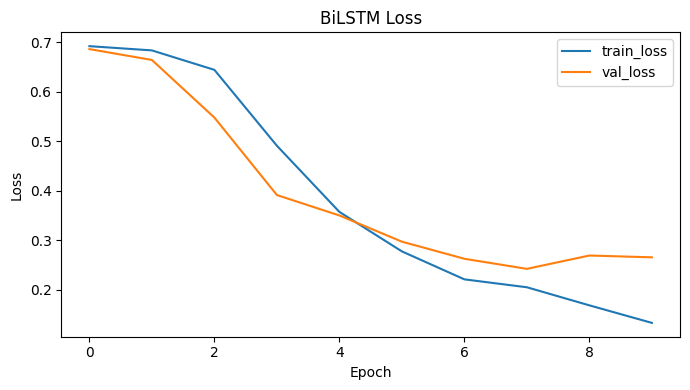

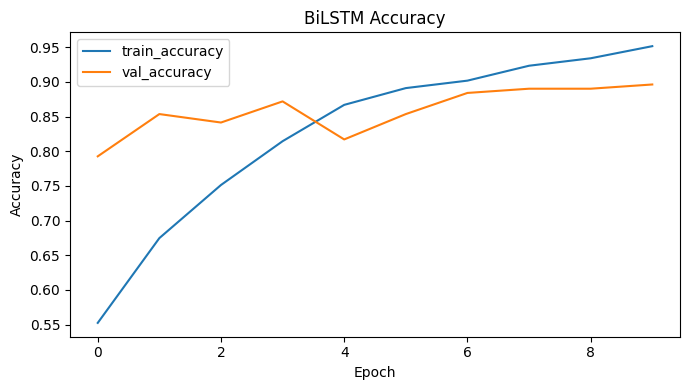

Saved loss plot: /content/drive/MyDrive/FP AI/outputs/figures/bilstm/bilstm_loss_curve.png
Saved accuracy plot: /content/drive/MyDrive/FP AI/outputs/figures/bilstm/bilstm_accuracy_curve.png


In [8]:
history_df = pd.DataFrame(history.history)
history_path = os.path.join(METRIC_DIR, "bilstm_training_history.csv")
history_df.to_csv(history_path, index=False)

print("Saved history:", history_path)
display(history_df.tail())

plt.figure(figsize=(7, 4))
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.title("BiLSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
loss_plot_path = os.path.join(BILSTM_FIGURE_DIR, "bilstm_loss_curve.png")
plt.tight_layout()
plt.savefig(loss_plot_path, dpi=200)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_df["accuracy"], label="train_accuracy")
plt.plot(history_df["val_accuracy"], label="val_accuracy")
plt.title("BiLSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
acc_plot_path = os.path.join(BILSTM_FIGURE_DIR, "bilstm_accuracy_curve.png")
plt.tight_layout()
plt.savefig(acc_plot_path, dpi=200)
plt.show()

print("Saved loss plot:", loss_plot_path)
print("Saved accuracy plot:", acc_plot_path)

## 8. Threshold tuning pada validation set

Bagian ini mencari threshold terbaik berdasarkan F1-score pada validation set.

Threshold terbaik digunakan untuk mengubah probabilitas sigmoid menjadi label klasifikasi.

In [9]:
valid_proba = bilstm_model.predict(X_valid, batch_size=BATCH_SIZE).reshape(-1)

thresholds = np.arange(0.10, 0.91, 0.01)
threshold_results = []

for threshold in thresholds:
    preds = (valid_proba >= threshold).astype(int)
    threshold_results.append({
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_valid, preds),
        "precision": precision_score(y_valid, preds, zero_division=0),
        "recall": recall_score(y_valid, preds, zero_division=0),
        "f1": f1_score(y_valid, preds, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_results)
best_row = threshold_df.sort_values(["f1", "recall", "precision"], ascending=False).iloc[0]
best_threshold = float(best_row["threshold"])

print("Best threshold based on validation F1:", best_threshold)
display(best_row.to_frame().T)

threshold_path = os.path.join(METRIC_DIR, "bilstm_threshold_search.csv")
threshold_df.to_csv(threshold_path, index=False)
print("Saved threshold search:", threshold_path)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step
Best threshold based on validation F1: 0.3699999999999999


,threshold,accuracy,precision,recall,f1
27,0.37,0.914634,0.902439,0.925,0.91358


Saved threshold search: /content/drive/MyDrive/FP AI/outputs/metrics/bilstm_threshold_search.csv


Threshold default biasanya `0.5`, tetapi threshold terbaik bisa berbeda.  
Karena itu, threshold dipilih berdasarkan F1-score pada validation set agar keseimbangan precision dan recall lebih optimal.

## 9. Evaluasi helper

Bagian ini berisi fungsi bantu untuk menghitung metrics dan membuat confusion matrix.

In [10]:
def evaluate_binary_classifier(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)

    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }

    try:
        metrics["roc_auc"] = float(roc_auc_score(y_true, y_proba))
    except Exception:
        metrics["roc_auc"] = None

    cm = confusion_matrix(y_true, y_pred)

    return metrics, y_pred, cm


def plot_confusion_matrix(cm, title, save_path):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks([0, 1], ["Human (0)", "AI (1)"])
    plt.yticks([0, 1], ["Human (0)", "AI (1)"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

## 10. Evaluasi validation dan test set

Bagian ini menghitung performa model pada validation set dan test set.

Metrics yang digunakan:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion matrix

In [11]:
# Validation inference time
valid_start = time.time()
valid_proba = bilstm_model.predict(X_valid, batch_size=BATCH_SIZE).reshape(-1)
valid_end = time.time()
valid_inference_time_seconds = valid_end - valid_start

valid_metrics, valid_pred, valid_cm = evaluate_binary_classifier(
    y_valid,
    valid_proba,
    threshold=best_threshold
)

# Test inference time
test_start = time.time()
test_proba = bilstm_model.predict(X_test, batch_size=BATCH_SIZE).reshape(-1)
test_end = time.time()
test_inference_time_seconds = test_end - test_start

test_metrics, test_pred, test_cm = evaluate_binary_classifier(
    y_test,
    test_proba,
    threshold=best_threshold
)

print("Validation metrics:")
print(json.dumps(valid_metrics, indent=4))

print("\nTest metrics:")
print(json.dumps(test_metrics, indent=4))

print("\nValidation classification report:")
print(classification_report(y_valid, valid_pred, target_names=["Human", "AI"], zero_division=0))

print("\nTest classification report:")
print(classification_report(y_test, test_pred, target_names=["Human", "AI"], zero_division=0))

print(f"Validation inference time: {valid_inference_time_seconds:.6f} seconds")
print(f"Test inference time: {test_inference_time_seconds:.6f} seconds")
print(f"Test inference time per sample: {test_inference_time_seconds / len(test_df):.8f} seconds")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Validation metrics:
{
    "accuracy": 0.9146341463414634,
    "precision": 0.9024390243902439,
    "recall": 0.925,
    "f1": 0.9135802469135802,
    "roc_auc": 0.9599702380952382
}

Test metrics:
{
    "accuracy": 0.7965116279069767,
    "precision": 0.7659574468085106,
    "recall": 0.8470588235294118,
    "f1": 0.8044692737430168,
    "roc_auc": 0.8862745098039216
}

Validation classification report:
              precision    recall  f1-score   support

       Human       0.93      0.90      0.92        84
          AI       0.90      0.93      0.91        80

    accuracy                           0.91       164
   macro avg       0.91      0.91      0.91       164
weighted avg       0.91      0.91      0.91       164


Test classification report:
              precision    recall  f1-score   support

       Human       0.83      0.75      0.79        87
          AI       0.77      0.85      0.80        8

Validation set digunakan untuk memantau dan memilih threshold.  
Test set digunakan sebagai evaluasi final untuk melihat kemampuan generalisasi model.

## 11. Plot confusion matrix

Bagian ini membuat visualisasi confusion matrix untuk validation dan test set.

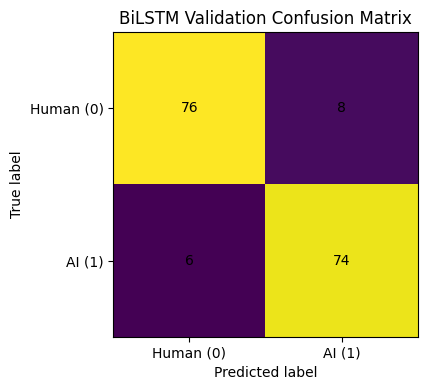

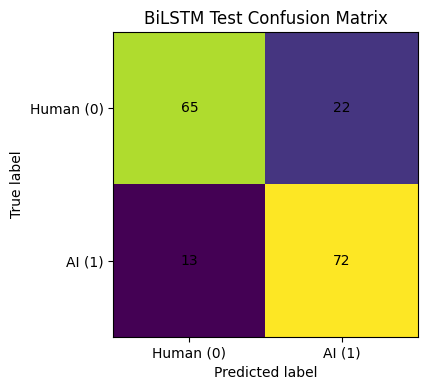

Saved validation confusion matrix: /content/drive/MyDrive/FP AI/outputs/figures/bilstm/bilstm_valid_confusion_matrix.png
Saved test confusion matrix: /content/drive/MyDrive/FP AI/outputs/figures/bilstm/bilstm_test_confusion_matrix.png


In [12]:
valid_cm_path = os.path.join(BILSTM_FIGURE_DIR, "bilstm_valid_confusion_matrix.png")
test_cm_path = os.path.join(BILSTM_FIGURE_DIR, "bilstm_test_confusion_matrix.png")

plot_confusion_matrix(
    valid_cm,
    "BiLSTM Validation Confusion Matrix",
    valid_cm_path
)

plot_confusion_matrix(
    test_cm,
    "BiLSTM Test Confusion Matrix",
    test_cm_path
)

print("Saved validation confusion matrix:", valid_cm_path)
print("Saved test confusion matrix:", test_cm_path)

## 12. Simpan prediction file

Bagian ini menyimpan hasil prediksi model untuk validation dan test set.

File ini berguna untuk:
- comparative analysis
- error analysis
- melihat false positive dan false negative

In [13]:
valid_pred_df = valid_df.copy()
valid_pred_df["y_true"] = y_valid
valid_pred_df["y_proba_ai"] = valid_proba
valid_pred_df["y_pred"] = valid_pred
valid_pred_df["model"] = "bilstm"

test_pred_df = test_df.copy()
test_pred_df["y_true"] = y_test
test_pred_df["y_proba_ai"] = test_proba
test_pred_df["y_pred"] = test_pred
test_pred_df["model"] = "bilstm"

valid_pred_path = os.path.join(PREDICTION_DIR, "bilstm_valid_predictions.csv")
test_pred_path = os.path.join(PREDICTION_DIR, "bilstm_test_predictions.csv")

valid_pred_df.to_csv(valid_pred_path, index=False)
test_pred_df.to_csv(test_pred_path, index=False)

print("Saved validation predictions:", valid_pred_path)
print("Saved test predictions:", test_pred_path)

display(test_pred_df[["problem_id", "label", "y_true", "y_pred", "y_proba_ai", "dataset_origin", "status_in_folder"]].head())

Saved validation predictions: /content/drive/MyDrive/FP AI/outputs/predictions/bilstm_valid_predictions.csv
Saved test predictions: /content/drive/MyDrive/FP AI/outputs/predictions/bilstm_test_predictions.csv


,problem_id,label,y_true,y_pred,y_proba_ai,dataset_origin,status_in_folder
0,p02777,1,1,0,0.350867,open,Generate
1,p03760,1,1,1,0.866296,open,Generate
2,p02662,0,0,1,0.514616,open,Accepted
3,p02574,0,0,0,0.115125,open,Accepted
4,p03606,1,1,1,0.930095,open,Generate


## 13. Simpan metrics

Bagian ini menyimpan ringkasan hasil model dalam format JSON dan CSV.

In [14]:
bilstm_summary = {
    "model": "BiLSTM",
    "feature_type": "regex token sequence + embedding + bidirectional LSTM",
    "input_used": "code only",
    "metadata_excluded": [
        "problem_id",
        "group_id",
        "leakage_group",
        "code_hash",
        "dataset_origin",
        "source_type",
        "status_in_folder",
        "LLM",
        "hf_split"
    ],
    "tokenization": {
        "max_vocab_size": MAX_VOCAB_SIZE,
        "effective_vocab_size": int(vocab_size),
        "max_sequence_length": MAX_SEQUENCE_LENGTH,
        "token_pattern": TOKEN_PATTERN.pattern
    },
    "architecture": {
        "embedding_dim": EMBEDDING_DIM,
        "lstm_units": LSTM_UNITS,
        "dropout_rate": DROPOUT_RATE,
        "batch_size": BATCH_SIZE,
        "max_epochs": EPOCHS,
        "actual_epochs": int(len(history_df))
    },
    "best_threshold_from_validation": best_threshold,
    "training_time_seconds": float(training_time_seconds),
    "validation_inference_time_seconds": float(valid_inference_time_seconds),
    "test_inference_time_seconds": float(test_inference_time_seconds),
    "test_inference_time_per_sample_seconds": float(test_inference_time_seconds / len(test_df)),
    "n_train": int(len(train_df)),
    "n_valid": int(len(valid_df)),
    "n_test": int(len(test_df)),
    "trainable_parameters": int(bilstm_model.count_params()),
    "validation_metrics": valid_metrics,
    "test_metrics": test_metrics,
    "validation_confusion_matrix": valid_cm.tolist(),
    "test_confusion_matrix": test_cm.tolist(),
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

summary_json_path = os.path.join(METRIC_DIR, "bilstm_metrics.json")
summary_csv_path = os.path.join(METRIC_DIR, "bilstm_metrics.csv")

with open(summary_json_path, "w") as f:
    json.dump(bilstm_summary, f, indent=4)

metrics_rows = [
    {
        "model": "BiLSTM",
        "split": "validation",
        **valid_metrics,
        "training_time_seconds": training_time_seconds,
        "inference_time_seconds": valid_inference_time_seconds,
        "inference_time_per_sample_seconds": valid_inference_time_seconds / len(valid_df),
        "threshold": best_threshold,
        "trainable_parameters": bilstm_model.count_params(),
    },
    {
        "model": "BiLSTM",
        "split": "test",
        **test_metrics,
        "training_time_seconds": training_time_seconds,
        "inference_time_seconds": test_inference_time_seconds,
        "inference_time_per_sample_seconds": test_inference_time_seconds / len(test_df),
        "threshold": best_threshold,
        "trainable_parameters": bilstm_model.count_params(),
    }
]

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(summary_csv_path, index=False)

print("Saved metrics JSON:", summary_json_path)
print("Saved metrics CSV:", summary_csv_path)
display(metrics_df)

Saved metrics JSON: /content/drive/MyDrive/FP AI/outputs/metrics/bilstm_metrics.json
Saved metrics CSV: /content/drive/MyDrive/FP AI/outputs/metrics/bilstm_metrics.csv


,model,split,accuracy,precision,recall,f1,roc_auc,training_time_seconds,inference_time_seconds,inference_time_per_sample_seconds,threshold,trainable_parameters
0,BiLSTM,validation,0.914634,0.902439,0.925000,0.913580,0.959970,27.7858,0.164570,0.001003,0.37,216385
1,BiLSTM,test,0.796512,0.765957,0.847059,0.804469,0.886275,27.7858,0.163723,0.000952,0.37,216385


## 14. Simpan model assets

Bagian ini menyimpan:
- final model
- best checkpoint
- tokenizer
- preprocessing config
- best threshold

In [15]:
final_model_path = os.path.join(BILSTM_MODEL_DIR, "bilstm_final_model.keras")
tokenizer_path = os.path.join(BILSTM_MODEL_DIR, "bilstm_tokenizer.pkl")
config_path = os.path.join(BILSTM_MODEL_DIR, "bilstm_preprocessing_config.json")
threshold_save_path = os.path.join(BILSTM_MODEL_DIR, "best_threshold.json")

bilstm_model.save(final_model_path)

with open(tokenizer_path, "wb") as f:
    pickle.dump(tokenizer, f)

preprocessing_config = {
    "max_vocab_size": MAX_VOCAB_SIZE,
    "effective_vocab_size": int(vocab_size),
    "max_sequence_length": MAX_SEQUENCE_LENGTH,
    "token_pattern": TOKEN_PATTERN.pattern,
    "padding": "post",
    "truncating": "post",
    "lower": False
}

with open(config_path, "w") as f:
    json.dump(preprocessing_config, f, indent=4)

with open(threshold_save_path, "w") as f:
    json.dump({"best_threshold": best_threshold}, f, indent=4)

print("Saved final model:", final_model_path)
print("Saved best checkpoint:", checkpoint_path)
print("Saved tokenizer:", tokenizer_path)
print("Saved preprocessing config:", config_path)
print("Saved threshold:", threshold_save_path)

Saved final model: /content/drive/MyDrive/FP AI/outputs/models/bilstm/bilstm_final_model.keras
Saved best checkpoint: /content/drive/MyDrive/FP AI/outputs/models/bilstm/bilstm_best_model.keras
Saved tokenizer: /content/drive/MyDrive/FP AI/outputs/models/bilstm/bilstm_tokenizer.pkl
Saved preprocessing config: /content/drive/MyDrive/FP AI/outputs/models/bilstm/bilstm_preprocessing_config.json
Saved threshold: /content/drive/MyDrive/FP AI/outputs/models/bilstm/best_threshold.json
